# 7CS033 Workshop 3 Exercises

Complete all the exercises.

First, try to solve the questions independently, and then review the solutions. If you are struggling with a question, try using independant research to look for useful functions to help solve the problem. Ensure you understand the given solution to each problem before moving on to the next.

We are using the titanic.csv data which can be found on Canvas.

## Importing necessary Libraries  

In [1]:
import pandas as pd
import numpy as np

###### Q1: Write code to import the titanic.csv data, print a sample of the data and identify the number of missing values in the dataset.

In [15]:
#Solution

df = pd.read_csv('titanic.csv')

print(df.sample(10))

print(pd.isnull(df).sum())

     PassengerId  Survived  Pclass                                     Name  \
853          854         1       1                Lines, Miss. Mary Conover   
16            17         0       3                     Rice, Master. Eugene   
239          240         0       2                   Hunt, Mr. George Henry   
81            82         1       3              Sheerlinck, Mr. Jan Baptist   
20            21         0       2                     Fynney, Mr. Joseph J   
472          473         1       2  West, Mrs. Edwy Arthur (Ada Mary Worth)   
100          101         0       3                  Petranec, Miss. Matilda   
500          501         0       3                         Calic, Mr. Petar   
704          705         0       3                  Hansen, Mr. Henrik Juul   
47            48         1       3                O'Driscoll, Miss. Bridget   

        Sex   Age  SibSp  Parch      Ticket     Fare Cabin Embarked  
853  female  16.0      0      1    PC 17592  39.4000   D28  

###### Q2: Write code to determine the different data types in this dataset. Identify a target variable.

In [3]:
print(df.dtypes)

#Target variable will be 'Survived'

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


###### Q3: Write code to appropriatley handle any missing values.

In [4]:
#Remove the cabin column 
df = df.drop(['Cabin'], axis = 1)

#inspect the age column to determine next steps
print(df['Age'].describe())

#Our mean and median are similar, our data appears symmetrical and as a first instance we can replace missing values with the median.
#To further improve our models we may wish to experiment with alternate methods later.

df['Age'] = df['Age'].fillna(df['Age'].median())

#we can use mode to fill the missing values in the embarked column
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
                                       
print(pd.isnull(df).sum())

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


###### Q4: Identify the relevant features and remove any other irrelevant features.

In [5]:
#Solution

#The other features to be removed are 'PassengerId', 'Ticket' and 'Name'. 

df = df.drop(['PassengerId', 'Ticket', 'Name'], axis = 1)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


###### Q5: Write code to encode the 'Sex' and 'Embarked' columns using LabelEncoder.

In [6]:
#Solution

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

print(df.head())


   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         0       3    1  22.0      1      0   7.2500         2
1         1       1    0  38.0      1      0  71.2833         0
2         1       3    0  26.0      0      0   7.9250         2
3         1       1    0  35.0      1      0  53.1000         2
4         0       3    1  35.0      0      0   8.0500         2


Note:

LabelEncoder assigns a unique value to each category. We must be cautious when using this method as when we assign numerical values to categorical variables we introduce order, even if order does not exist. When training a model it could interpret the order of those labels as having meaning even if no meaning exists. For binary classification this is not an issue, which is why in this example we would have no issues using LabelEncoder for the 'Sex' feature. 

However, given that 'Embarked' is a multiclass nominal feature it would have been more more appropriate to use alternate encoding methods such as One-Hot Encoding. One hot encoding is useful for nominal categorical variables as this method creates a binary column for each category. This ensures no order is introduced as the categories are independent. This method increases the number of features in the data, one additional feature for each category being encoded, which can greatly increase the dimensionality of the dataset.

You may find it useful to look into the OrdinalEncoder method, this works in a similar way to label encoder but can be quickly applied to multiple features at once. Typically, LabelEncoder is used on the target variable and OrdinalEncoder is used for any ordinal input features, where the order does have meaning.


###### Q6: Write a function that takes in a feature name and ouputs a histogram for that feature. 

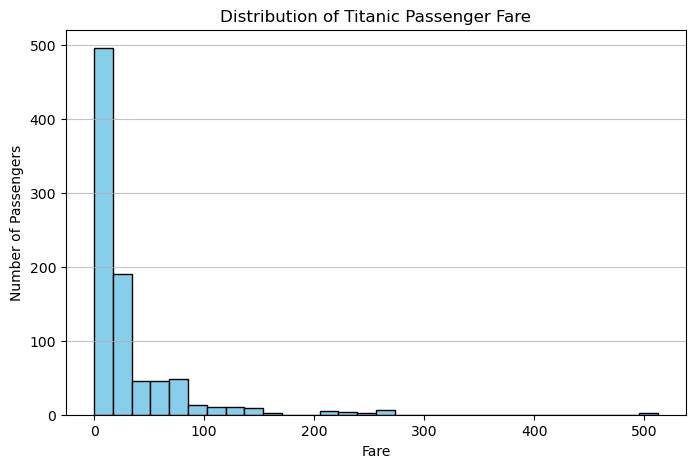

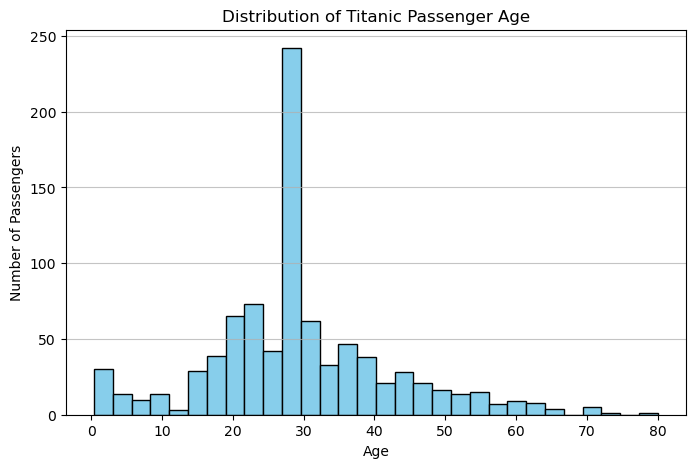

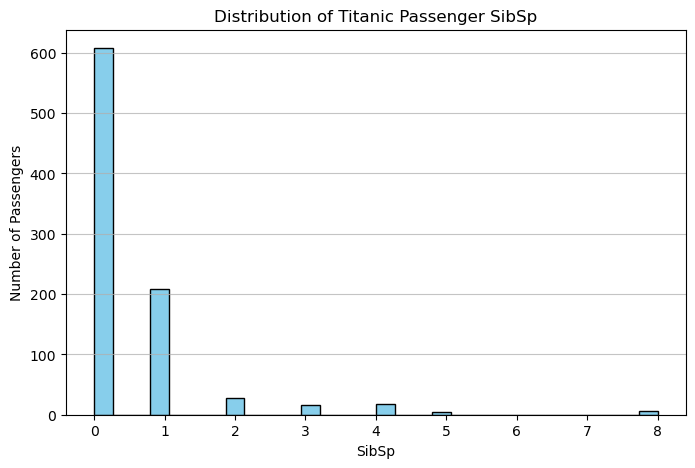

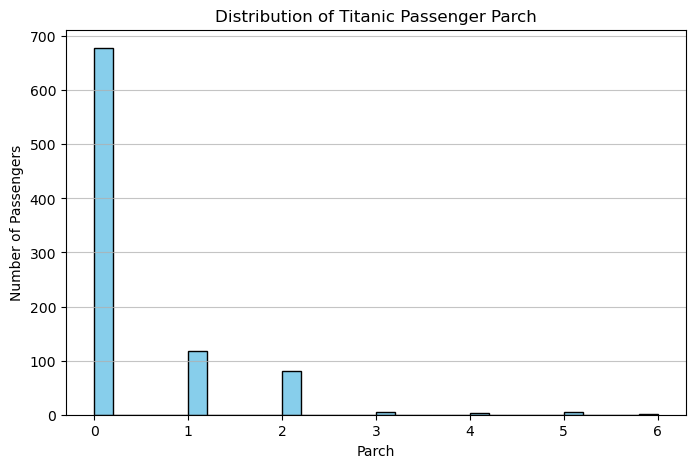

In [7]:
#Solution

import matplotlib.pyplot as plt

def histplot(feature_name):
    plt.figure(figsize=(8,5))
    plt.hist(df[feature_name], bins=30, color='skyblue', edgecolor='black')
    plt.title('Distribution of Titanic Passenger ' + feature_name)
    plt.xlabel(feature_name)
    plt.ylabel('Number of Passengers')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

histplot('Fare')
histplot('Age')
histplot('SibSp')
histplot('Parch')

###### Q6: Write code to apply a log transfomation to the 'Fare' column to reduce skew, plot a new histogram after transforming this feature.

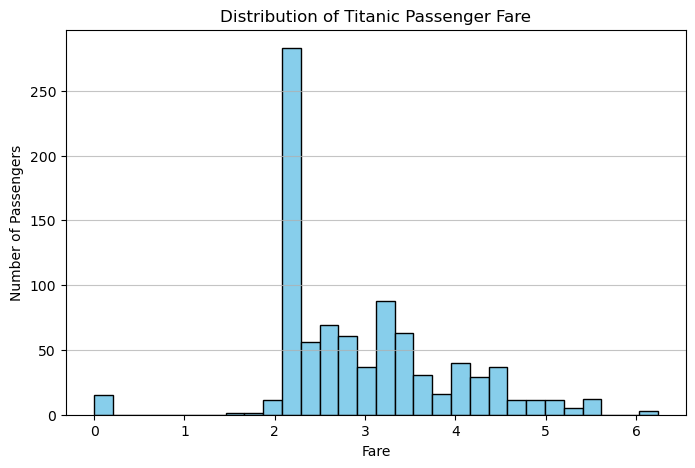

In [8]:
#Solution

df['Fare'] = np.log1p(df['Fare'])
histplot('Fare')

#Note: We could consider transforming the SibSp and Parch as well. However, these features are discrete counts and are not continuous.
#Applying a log transform to these features could make the differences in the values more difficult for the models to intepret. We could
#experiment with this and see what the data looks like after transforming and if this has any impact on our model performance.

###### Q7: Write code to apply MinMaxScaler to 'Fare' and 'Age' columns.

In [10]:
#Solution
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[['Fare', 'Age']] = scaler.fit_transform(df[['Fare', 'Age']])
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,0.271174,1,0,0.338125,2
1,1,1,0,0.472229,1,0,0.685892,0
2,1,3,0,0.321438,0,0,0.350727,2
3,1,1,0,0.434531,1,0,0.639463,2
4,0,3,1,0.434531,0,0,0.352955,2


###### Q8: Write code to make appropriate training and test sets with an 80/20 split.

In [11]:
#Solution

X = df.drop('Survived', axis = 1)
y = df.iloc[:, 0]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

###### Q9: Write code to apply the four models discussed in this weeks lecture (SVM, DT, RF and KNN) to this data.

In [12]:
# Solution

from sklearn import svm
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

SVM = svm.SVC()
DT = DecisionTreeClassifier()
RF = RandomForestClassifier()
KNN = KNeighborsClassifier()


SVM.fit(X_train, y_train)
DT.fit(X_train, y_train)
RF.fit(X_train, y_train)
KNN.fit(X_train, y_train)

KNeighborsClassifier()

###### Q10: Write code to calculate the confusion matrix for each model.

Text(0.5, 1.0, 'KNN')

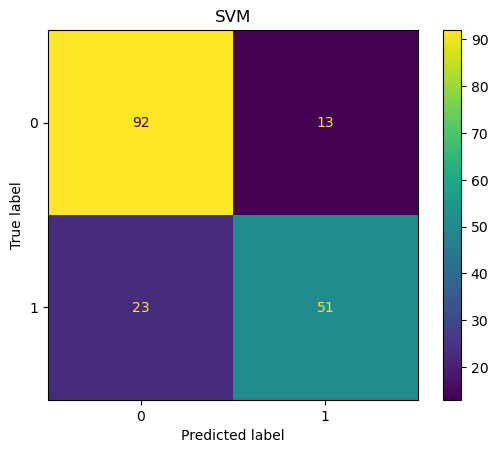

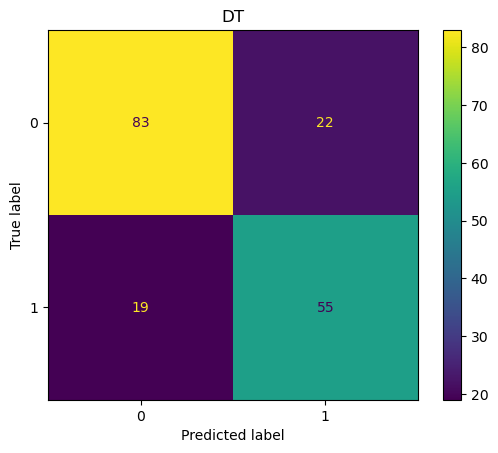

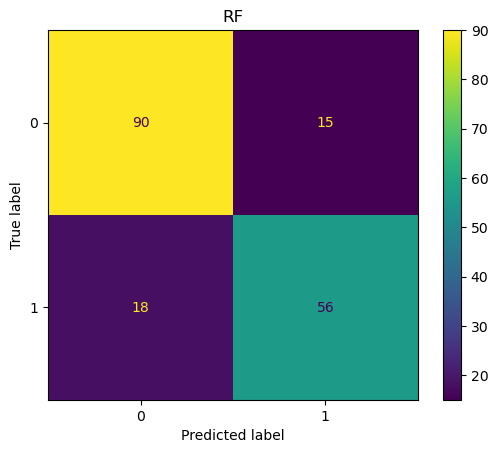

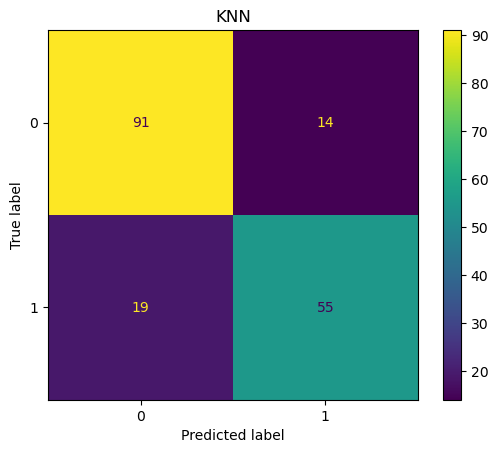

In [13]:
#Solution

#first make predictions using our trained models on the test data

SVM_pred = SVM.predict(X_test)
DT_pred = DT.predict(X_test)
RF_pred = RF.predict(X_test)
KNN_pred = KNN.predict(X_test)

#Now we can generate the confusion matrices

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

SVM_cm = confusion_matrix(y_test, SVM_pred, labels = SVM.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = SVM_cm, display_labels = SVM.classes_)
disp.plot()
plt.title('SVM')

DT_cm = confusion_matrix(y_test, DT_pred, labels = DT.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = DT_cm, display_labels = DT.classes_)
disp.plot()
plt.title('DT')

RF_cm = confusion_matrix(y_test, RF_pred, labels = RF.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = RF_cm, display_labels = RF.classes_)
disp.plot()
plt.title('RF')

KNN_cm = confusion_matrix(y_test, KNN_pred, labels = KNN.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = KNN_cm, display_labels = KNN.classes_)
disp.plot()
plt.title('KNN')

#Note: You may find it useful to try calculating some evaluation metrics by hand using your confusion matrices before moving on to the next 
#question

###### Q11: Write code to display accuracy, precision, recall and F1 score for each of the models.

In [14]:
#Solution 

from sklearn import metrics

print('SVM Metrics \n')
print('Accuracy: %.2f' %metrics.accuracy_score(y_test, SVM_pred))
print('Precision: %.2f' %metrics.precision_score(y_test, SVM_pred))
print('Recall: %.2f' %metrics.recall_score(y_test, SVM_pred))
print('F1 Score: %.2f \n' %metrics.f1_score(y_test, SVM_pred))

print('DT Metrics \n')
print('Accuracy: %.2f' %metrics.accuracy_score(y_test, DT_pred))
print('Precision: %.2f' %metrics.precision_score(y_test, DT_pred))
print('Recall: %.2f' %metrics.recall_score(y_test, DT_pred))
print('F1 Score: %.2f \n' %metrics.f1_score(y_test, DT_pred))

print('RF Metrics \n')
print('Accuracy: %.2f' %metrics.accuracy_score(y_test, RF_pred))
print('Precision: %.2f' %metrics.precision_score(y_test, RF_pred))
print('Recall: %.2f' %metrics.recall_score(y_test, RF_pred))
print('F1 Score: %.2f \n' %metrics.f1_score(y_test, RF_pred))

print('KNN Metrics \n')
print('Accuracy: %.2f' %metrics.accuracy_score(y_test, KNN_pred))
print('Precision: %.2f' %metrics.precision_score(y_test, KNN_pred))
print('Recall: %.2f' %metrics.recall_score(y_test, KNN_pred))
print('F1 Score: %.2f \n' %metrics.f1_score(y_test, KNN_pred))

#Note: What do you notice?

SVM Metrics 

Accuracy: 0.80
Precision: 0.80
Recall: 0.69
F1 Score: 0.74 

DT Metrics 

Accuracy: 0.77
Precision: 0.71
Recall: 0.74
F1 Score: 0.73 

RF Metrics 

Accuracy: 0.82
Precision: 0.79
Recall: 0.76
F1 Score: 0.77 

KNN Metrics 

Accuracy: 0.82
Precision: 0.80
Recall: 0.74
F1 Score: 0.77 

